## Epilepsy-Focal Cortical Dysplasia Type II Data Preparation

The presurgery MRI dataset of people with epilepsy and focal cortical dysplasia type II [https://openneuro.org/datasets/ds004199/versions/1.0.6] contains \(N=85\) labeled samples and 85 unlabeled samples. We reserve 10 samples here for validation. Each training example consists of one modality (FLAIR) and a mask annotated by expert radiologists. The mask includes the following labels:

- **0**: background  
- **1**: head 
- **2**: focal cortical dysplasia type II 

An additional label for the "head" is introduced. This is done by incrementing each non-background label by 1, followed by using Otsu thresholding from scikit-image to detect the head region, which is assigned label 1. As a result, the final anatomical masks have **3** channels (see the figure below). Adding the head region accelerates the model's learning of head generation. 

Next, all samples are linearly normalized to $[0,1]$ for consistency, as the original BraTS volumes have varying intensity ranges. Finally, volumes are padded and cropped from $(160, 256, 256) → (80, 128, 128)$ to ensure compatibility with the **3D U-Net** used in the diffusion routine, which requires dimensions to be multiples of 16. 

In [ ]:
import numpy as np
import nibabel as nib
img = nib.load("Epilepsy-FCDT2/sub-00003/anat/sub-00003_acq-T2sel_FLAIR_roi.nii.gz")
seg_data = img.get_fdata().astype(np.int32)

nonzero_pixels = 0

for slice in seg_data:
    for row in slice:
        for pixel in row:
            if pixel != 0:
                print(pixel)


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


Raw image size: (160, 256, 256)
Bias correction complete.
Bounding box: (0, 13, 1, 160, 209, 215)
Resized image to: (96, 128, 160)
Intensity normalization complete.
Skull stripping complete.
Images saved.


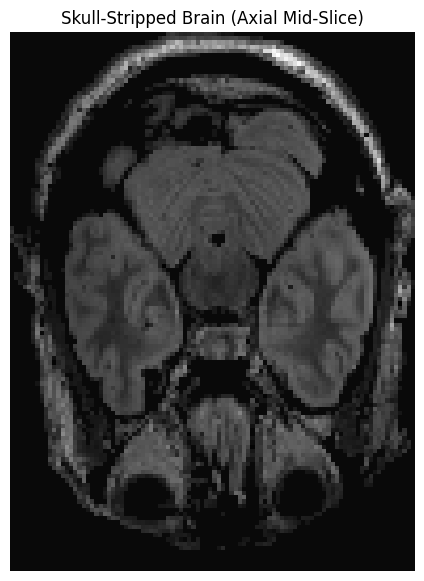

In [ ]:
roi_path = "Epilepsy-FCDT2/sub-00003/anat/sub-00003_acq-T2sel_FLAIR_roi.nii.gz"
FLAIR_path = "Epilepsy-FCDT2/sub-00003/anat/sub-00003_acq-T2sel_FLAIR.nii.gz"

